In [34]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# TensorFlow / Keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

In [35]:
df = pd.read_csv("customer_churn_nn.csv")
df.head()

,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [36]:
print("Rows and Columns:", df.shape)

Rows and Columns: (2000, 17)


In [37]:
print(df.dtypes)

customer_id                         str
region                              str
plan_type                           str
contract_type                       str
payment_method                      str
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn                             int64
dtype: object


In [38]:
print(df['churn'].value_counts())

churn
0    1969
1      31
Name: count, dtype: int64


In [39]:
print(df.isnull().sum())

customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64


In [40]:
print(df.describe())

       tenure_months  monthly_charges_inr  avg_login_days_per_month  \
count    2000.000000          2000.000000               2000.000000   
mean       25.362000           766.487295                 18.099000   
std        14.128651           393.420070                  5.400628   
min         1.000000           255.450000                  0.000000   
25%        15.000000           427.782500                 15.000000   
50%        23.000000           688.355000                 18.000000   
75%        33.000000          1007.372500                 22.000000   
max        72.000000          2156.520000                 30.000000   

       support_tickets_last_90_days  payment_delay_days  data_usage_gb  \
count                   2000.000000         2000.000000    2000.000000   
mean                       1.953000            3.555000      90.007625   
std                        1.463852            3.885682      53.215719   
min                        0.000000            0.000000       0.

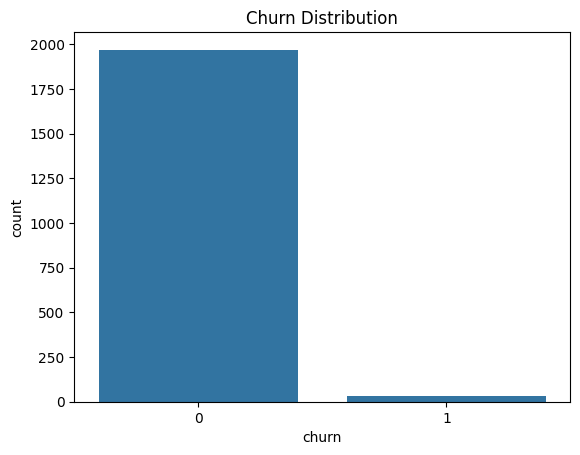

In [41]:
# Visualize the distribution of the target variable 'churn'
sns.countplot(x='churn', data=df)
plt.title("Churn Distribution")

plt.show()

## Task 2: Data Preprocessing

In [42]:
df = df.drop('customer_id', axis=1)

In [43]:
X = df.drop('churn', axis=1)
y = df['churn']

Categorical and Numerical Columns

In [44]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   region                        2000 non-null   str    
 1   plan_type                     2000 non-null   str    
 2   contract_type                 2000 non-null   str    
 3   payment_method                2000 non-null   str    
 4   tenure_months                 2000 non-null   int64  
 5   monthly_charges_inr           2000 non-null   float64
 6   avg_login_days_per_month      2000 non-null   int64  
 7   support_tickets_last_90_days  2000 non-null   int64  
 8   payment_delay_days            2000 non-null   int64  
 9   data_usage_gb                 2000 non-null   float64
 10  satisfaction_score            2000 non-null   float64
 11  last_complaint_days_ago       2000 non-null   int64  
 12  discount_percent              2000 non-null   int64  
 13  autopay_enable

In [45]:
categorical_cols = ['region', 'plan_type', 'contract_type', 'payment_method']
numerical_cols = [col for col in X.columns if col not in categorical_cols]

Preprocessing Pipeline

In [46]:
from sklearn.preprocessing import OneHotEncoder

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

Train Test Split

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Apply Preprocessing

In [48]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

## Task 3: Neural Network Model Building

In [49]:
model = Sequential()

# Input + Hidden Layer
model.add(Dense(32, activation='relu', input_shape=(X_train.shape[1],)))

# Hidden Layer
model.add(Dense(16, activation='relu'))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

e:\massai\codes\assignments\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [50]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [51]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 32)             │           928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,473 (5.75 KB)

 Trainable params: 1,473 (5.75 KB)

 Non-trainable params: 0 (0.00 B)

## Task 4: Training and Evaluation

In [52]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 14s 41ms/step - accuracy: 0.9156 - loss: 0.4123 - val_accuracy: 0.9781 - val_loss: 0.2216
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9867 - loss: 0.1384 - val_accuracy: 0.9781 - val_loss: 0.1189
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9867 - loss: 0.0829 - val_accuracy: 0.9781 - val_loss: 0.1067
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9867 - loss: 0.0722 - val_accuracy: 0.9781 - val_loss: 0.1024
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9867 - loss: 0.0675 - val_accuracy: 0.9781 - val_loss: 0.0984
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9867 - loss: 0.0639 - val_accuracy: 0.9781 - val_loss: 0.0978
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9867 - loss: 0.0613 - val_accuracy: 0.9781 - val_loss: 0.0958
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9867 - loss: 0.0589 - val_accuracy: 0.9781 - val_lo

In [53]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy: 0.9825 - loss: 0.0698 
Test Loss: 0.06982304155826569
Test Accuracy: 0.9825000166893005


In [54]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


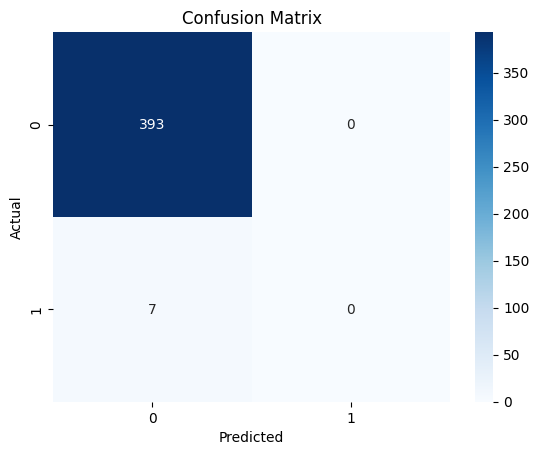

In [55]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [56]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       393
           1       0.00      0.00      0.00         7

    accuracy                           0.98       400
   macro avg       0.49      0.50      0.50       400
weighted avg       0.97      0.98      0.97       400



e:\massai\codes\assignments\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\massai\codes\assignments\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\massai\codes\assignments\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


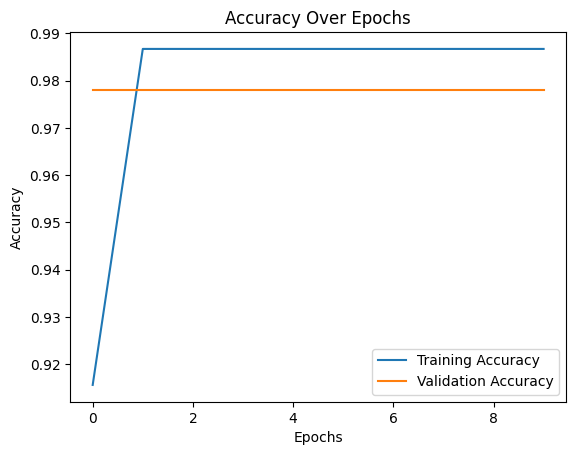

In [57]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Accuracy Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

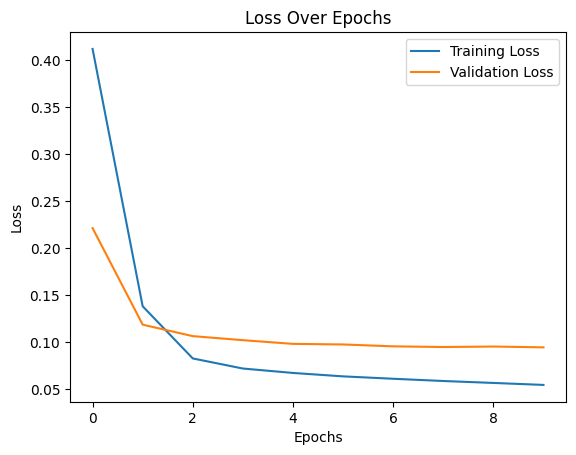

In [58]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()  

Brief Interpretation

Example:

The neural network achieved good accuracy on the test dataset.
The confusion matrix shows the model correctly classified most customers.
Validation accuracy remained close to training accuracy, indicating stable learning.

## Task 5: Hyperparameter Experimentation

In [59]:
model1 = Sequential([
    Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(1, activation='sigmoid')
])

model1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history1 = model1.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
acc1 = model1.evaluate(X_test, y_test, verbose=0)[1]

e:\massai\codes\assignments\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [60]:
model2 = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history2 = model2.fit(X_train, y_train, epochs=20, batch_size=32, verbose=0)
acc2 = model2.evaluate(X_test, y_test, verbose=0)[1]

In [61]:
model3 = Sequential([
    Dense(64, activation='tanh', input_shape=(X_train.shape[1],)),
    Dense(32, activation='tanh'),
    Dense(1, activation='sigmoid')
])

model3.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history3 = model3.fit(X_train, y_train, epochs=30, batch_size=64, verbose=0)
acc3 = model3.evaluate(X_test, y_test, verbose=0)[1]

In [62]:
comparison = pd.DataFrame({
    'Experiment': ['Exp 1', 'Exp 2', 'Exp 3'],
    'Hidden Layers': [1, 2, 2],
    'Neurons': ['16', '64-32', '64-32'],
    'Activation': ['ReLU', 'ReLU', 'Tanh'],
    'Epochs': [10, 20, 30],
    'Batch Size': [32, 32, 64],
    'Test Accuracy': [acc1, acc2, acc3]
})

print(comparison)

  Experiment  Hidden Layers Neurons Activation  Epochs  Batch Size  \
0      Exp 1              1      16       ReLU      10          32   
1      Exp 2              2   64-32       ReLU      20          32   
2      Exp 3              2   64-32       Tanh      30          64   

   Test Accuracy  
0         0.9825  
1         0.9775  
2         0.9800  


## Task 6: Final Reflection
1. Role of Weights and Biases

Weights determine the importance of input features in prediction.
Biases help shift the activation function and improve flexibility in learning patterns.

2. Why Activation Function is Required

Activation functions allow neural networks to learn non-linear relationships.
Without activation functions, the neural network would behave like a simple linear model.

3. Effect of Learning Rate
If learning rate is too high:
Model may skip optimal solution
Training becomes unstable
If learning rate is too low:
Training becomes very slow
Model may take too long to converge
4. Underfitting or Overfitting

Example explanation:

The model showed slight overfitting because training accuracy became higher than validation accuracy after several epochs.
However, the difference was not extremely large, indicating acceptable generalization performance.